### Cell 1 – Imports, data generation, and split

In this cell we generate a synthetic two‑class dataset using `make_moons`, then split it into training and test sets. To create a semi‑supervised setting, we keep labels for only 100 training points and treat the remaining 700 as unlabeled. We then standardise the features so that the Random Forest sees all inputs on a comparable scale.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                  random_state=42, stratify=y)

n_labeled = 100
indices = np.random.permutation(len(X_train))
X_labeled = X_train[indices[:n_labeled]]
y_labeled = y_train[indices[:n_labeled]]
X_unlabeled = X_train[indices[n_labeled:]]
y_unlabeled_true = y_train[indices[n_labeled:]]

scaler = StandardScaler()
X_labeled = scaler.fit_transform(X_labeled)
X_unlabeled = scaler.transform(X_unlabeled)
X_test = scaler.transform(X_test)


### Cell 2 – Visualise the dataset

Here we plot the make_moons data with the true class labels. This scatter plot shows the two interlocking half‑moons and makes it clear that the decision boundary is curved and non‑linear, which is why tree‑based models such as Random Forest are a good choice.

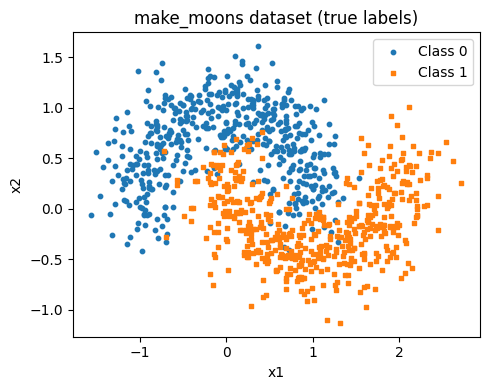

In [ ]:
plt.figure(figsize=(5, 4))
for label, marker in zip([0, 1], ['o', 's']):
    plt.scatter(
        X[y == label, 0],
        X[y == label, 1],
        c=['#1f77b4', '#ff7f0e'][label],
        marker=marker,
        s=10,
        label=f"Class {label}"
    )
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("make_moons dataset (true labels)")
plt.legend()
plt.tight_layout()
plt.show()

### Cell 3 – Baseline Random Forest (supervised only)

This cell trains a standard `RandomForestClassifier` using only the 100 labeled training points and evaluates it on the test set. The resulting accuracy is our supervised baseline, which we will later compare to the self‑training models that also use the unlabeled data.

In [ ]:
def self_training(X_labeled, y_labeled, X_unlabeled, base_model,
                  threshold=0.9, max_iter=10):
    model = base_model
    X_l = X_labeled.copy()
    y_l = y_labeled.copy()
    X_u = X_unlabeled.copy()

    added_per_iter = []

    for i in range(max_iter):
        model.fit(X_l, y_l)

        if len(X_u) == 0:
            print(f"Iteration {i}: no unlabeled data left.")
            break

        proba = model.predict_proba(X_u)
        confidence = proba.max(axis=1)
        y_u_pred = proba.argmax(axis=1)
        confident_idx = np.where(confidence >= threshold)[0]
        print(f"Iteration {i}: {len(confident_idx)} high-confidence points "
              f"(labeled so far: {len(y_l)})")

        added_per_iter.append(len(confident_idx))

        if len(confident_idx) == 0:
            print("No more confident points; stopping.")
            break

        X_l = np.vstack((X_l, X_u[confident_idx]))
        y_l = np.hstack((y_l, y_u_pred[confident_idx]))
        X_u = np.delete(X_u, confident_idx, axis=0)

    return model, X_l, y_l, X_u, added_per_iter


### Cell 4 – Self‑training function

Here we define a `self_training` function that implements the semi‑supervised loop. In each iteration the Random Forest is trained on the current labeled set, predicts class probabilities for all unlabeled points, selects those above a chosen confidence threshold, assigns pseudo‑labels, and moves them into the labeled pool. The function also tracks how many pseudo‑labels are added per iteration.

In [ ]:
rf_baseline = RandomForestClassifier(n_estimators=200, max_depth=None,
                                     random_state=42)
rf_baseline.fit(X_labeled, y_labeled)
y_pred_base = rf_baseline.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print("Initially labeled count:", len(y_labeled))
print("Initially unlabeled count:", len(X_unlabeled))
print(f"Baseline RF accuracy (no self-training): {acc_base:.3f}")


Initially labeled count: 100
Initially unlabeled count: 700
Baseline RF accuracy (no self-training): 0.940


### Cell 5 – Run self‑training for multiple thresholds

In this cell we run the self‑training procedure for three different confidence thresholds: 0.8, 0.9, and 0.95. For each threshold we record the final test accuracy, the number of labeled and unlabeled points, and how many high‑confidence pseudo‑labels were added in each iteration. This lets us study how aggressive vs conservative thresholds change both performance and dataset size.

In [ ]:
thresholds = [0.8, 0.9, 0.95]
results = []

for thr in thresholds:
    print("\n==============================")
    print(f"Self-training with threshold = {thr}")
    print("==============================")

    base_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                        random_state=42)

    rf_thr, X_l_thr, y_l_thr, X_u_thr, added_thr = self_training(X_labeled,
                                                                 y_labeled,
                                                                 X_unlabeled,
                                                                 base_model,
                                                                 threshold=thr,
                                                                 max_iter=10)

    acc_thr = accuracy_score(y_test, rf_thr.predict(X_test))

    print(f"Threshold {thr}: acc = {acc_thr:.3f}, "
          f"final labeled = {len(y_l_thr)}, "
          f"remaining unlabeled = {len(X_u_thr)}, "
          f"added per iter = {added_thr}")

    results.append((thr, acc_thr, len(y_l_thr), len(X_u_thr), added_thr))



Self-training with threshold = 0.8
Iteration 0: 587 high-confidence points (labeled so far: 100)
Iteration 1: 68 high-confidence points (labeled so far: 687)
Iteration 2: 22 high-confidence points (labeled so far: 755)
Iteration 3: 4 high-confidence points (labeled so far: 777)
Iteration 4: 4 high-confidence points (labeled so far: 781)
Iteration 5: 3 high-confidence points (labeled so far: 785)
Iteration 6: 1 high-confidence points (labeled so far: 788)
Iteration 7: 0 high-confidence points (labeled so far: 789)
No more confident points; stopping.
Threshold 0.8: acc = 0.915, final labeled = 789, remaining unlabeled = 11, added per iter = [587, 68, 22, 4, 4, 3, 1, 0]

Self-training with threshold = 0.9
Iteration 0: 494 high-confidence points (labeled so far: 100)
Iteration 1: 86 high-confidence points (labeled so far: 594)
Iteration 2: 18 high-confidence points (labeled so far: 680)
Iteration 3: 7 high-confidence points (labeled so far: 698)
Iteration 4: 9 high-confidence points (labe

### Cell 6 – Summary table (including baseline)

Here we print a compact summary of the baseline and all self‑training runs. The table shows accuracy, the final size of the labeled set, remaining unlabeled points, and pseudo‑labels added per iteration. This acts as a quick teaching summary of the accuracy–threshold trade‑off.

In [ ]:
print("\nSummary (including baseline):")
print(f"Baseline (no self-training): acc = {acc_base:.3f}, "
      f"labeled = {len(y_labeled)}")

for thr, acc_thr, n_lab, n_unlab, added in results:
    print(f"Threshold {thr}: acc = {acc_thr:.3f}, "
          f"labeled = {n_lab}, remaining unlabeled = {n_unlab}, "
          f"added per iter = {added}")



Summary (including baseline):
Baseline (no self-training): acc = 0.940, labeled = 100
Threshold 0.8: acc = 0.915, labeled = 789, remaining unlabeled = 11, added per iter = [587, 68, 22, 4, 4, 3, 1, 0]
Threshold 0.9: acc = 0.925, labeled = 719, remaining unlabeled = 81, added per iter = [494, 86, 18, 7, 9, 5, 0]
Threshold 0.95: acc = 0.940, labeled = 631, remaining unlabeled = 169, added per iter = [380, 76, 37, 11, 9, 9, 2, 4, 2, 1]


### Cell 7 – Baseline vs self‑training decision boundary

This cell plots test predictions for the baseline Random Forest and for one self‑training model with a chosen threshold. Correctly classified points are shown with circle markers and misclassified points with crosses, so we can visually compare how the decision boundary changes and where each model still makes mistakes.

Iteration 0: 494 high-confidence points (labeled so far: 100)
Iteration 1: 86 high-confidence points (labeled so far: 594)
Iteration 2: 18 high-confidence points (labeled so far: 680)
Iteration 3: 7 high-confidence points (labeled so far: 698)
Iteration 4: 9 high-confidence points (labeled so far: 705)
Iteration 5: 5 high-confidence points (labeled so far: 714)
Iteration 6: 0 high-confidence points (labeled so far: 719)
No more confident points; stopping.
Chosen threshold 0.9: acc = 0.925
Pseudo-labels added per iteration: [494, 86, 18, 7, 9, 5, 0]


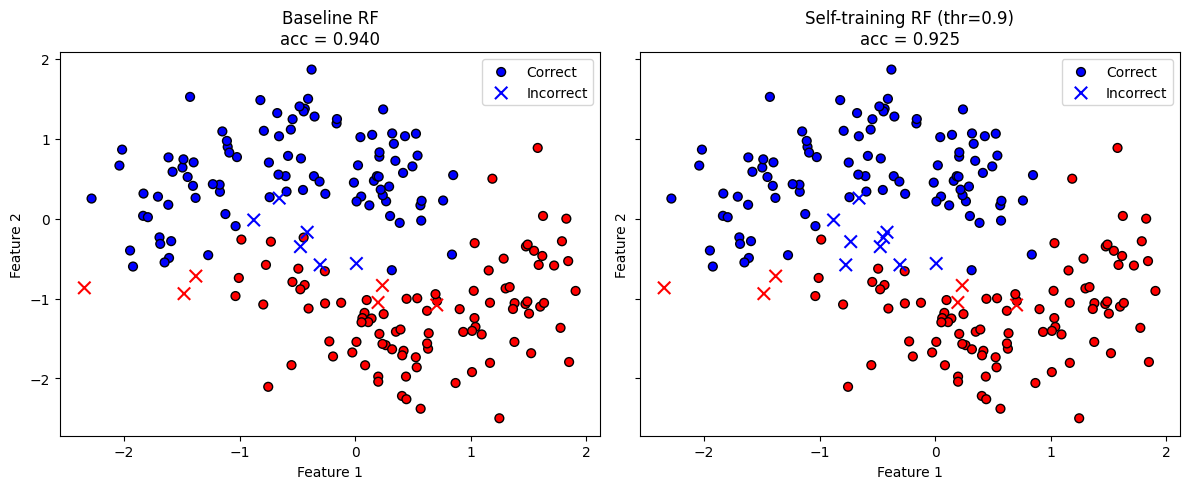

In [ ]:
chosen_thr = 0.9

base_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                    random_state=42)
rf_self, X_l_final, y_l_final, X_u_final, added_per_iter = self_training(
    X_labeled, y_labeled, X_unlabeled, base_model,threshold=chosen_thr,
    max_iter=10)

y_pred_self = rf_self.predict(X_test)
acc_self = accuracy_score(y_test, y_pred_self)

print(f"Chosen threshold {chosen_thr}: acc = {acc_self:.3f}")
print("Pseudo-labels added per iteration:", added_per_iter)

def plot_predictions(X, y_true, y_pred, title, ax):
    correct = y_pred == y_true
    incorrect = ~correct

    ax.scatter(X[correct, 0],X[correct, 1],c=y_pred[correct],cmap="bwr",
               marker="o",edgecolor="k",s=40,label="Correct")
    if incorrect.any():
        ax.scatter(X[incorrect, 0],X[incorrect, 1],c=y_pred[incorrect],
                   cmap="bwr",marker="x",s=80,label="Incorrect")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_title(title)
    ax.legend(loc="best")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

plot_predictions(X_test, y_test, y_pred_base,
                 f"Baseline RF\nacc = {acc_base:.3f}", axes[0])
plot_predictions(X_test, y_test, y_pred_self,
                 f"Self-training RF (thr={chosen_thr})\nacc = {acc_self:.3f}",
                 axes[1])

plt.tight_layout()
plt.show()


## Discussion and accessibility

On this make_moons task, the supervised Random Forest trained on only 100 labeled points already achieves high accuracy, so self‑training does not always improve performance. A low threshold (0.8) adds many pseudo‑labels and slightly boosts accuracy but risks introducing noisy labels. Medium and high thresholds (0.9 and 0.95) are more conservative: they add fewer, more reliable pseudo‑labels, keep accuracy close to the baseline, and illustrate the trade‑off between using more unlabeled data and avoiding label noise.

All plots in this notebook use clear axis labels, titles, legends, and a combination of colour and marker shapes (for example, circles vs squares or crosses). Numeric information, such as accuracy values, is also printed in text form. These choices are intended to keep the visualisations readable for colour‑blind readers and for anyone viewing the notebook in greyscale or on printed pages.

> Note on randomness and reproducibility  
> We use fixed `random_state` values when generating the data and splitting into train/test sets so that results are broadly reproducible. However, because we randomly choose which 100 training points are treated as labeled, the exact accuracies and numbers of pseudo‑labeled points can vary slightly between runs. The overall patterns for each threshold remain the same.